Size of training set: 30000
Size of test set: 5000
Shape of training point: (torch.Size([1, 28, 28]), torch.Size([]))
Shape of test point: (torch.Size([1, 28, 28]), torch.Size([]))


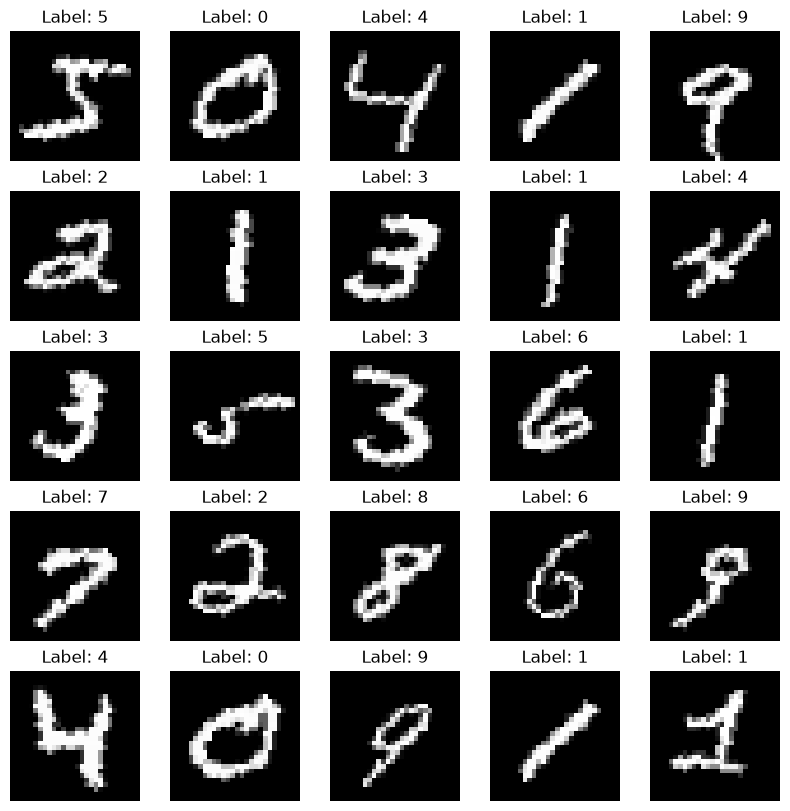

In [ ]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid


DATA_PATH = "../data/corruptmnist_v1"

def corrupt_mnist():
    train_images, train_target = [], []
    for i in range(6):
        train_images.append(torch.load(f"{DATA_PATH}/train_images_{i}.pt"))
        train_target.append(torch.load(f"{DATA_PATH}/train_target_{i}.pt"))

    train_images=torch.cat(train_images)
    # print(f"Train images shape: {train_images.shape}")
    train_target=torch.cat(train_target)
    # print(f"Train target: {train_target}")


    test_images = torch.load(f"{DATA_PATH}/test_images.pt")
    test_target = torch.load(f"{DATA_PATH}/test_target.pt")

    train_images = train_images.unsqueeze(1).float()
    # print(f"Train images unsqueeze: {train_images}")
    # print(f"Train images unsqueeze shape: {train_images.shape}")
    test_images = test_images.unsqueeze(1).float()
    train_target = train_target.long()
    # print(f"Train images long: {train_images}")

    test_target = test_target.long()

    train_set = torch.utils.data.TensorDataset(train_images, train_target)
    test_set = torch.utils.data.TensorDataset(test_images, test_target)

    return train_set, test_set

def show_image_and_target(images, target):
    row_col = int(len(images)**0.5)
    fig = plt.figure(figsize=(10.0, 10.0))
    grid = ImageGrid(fig, 111, nrows_ncols=(row_col, row_col), axes_pad=0.3)
    for ax, im, label in zip(grid, images, target):
        ax.imshow(im.squeeze(), cmap="gray")
        ax.set_title(f"Label: {label.item()}")
        ax.axis("off")
    plt.show()

if __name__=="__main__":
    train_set, test_set = corrupt_mnist()
    print(train_set)
    print(f"Size of training set: {len(train_set)}")
    print(f"Size of test set: {len(test_set)}")
    print(f"Shape of training point: {(train_set[0][0].shape, train_set[0][1].shape)}")
    print(f"Shape of test point: {(test_set[0][0].shape, test_set[0][1].shape)}")
    show_image_and_target(train_set.tensors[0][:25], train_set.tensors[1][:25])
    







